Seojin

# Notice

You can visualize plot only in mac. I tested vedo in Ubuntu, but It did not work.

# Vedo(Visualization of эD Objects)

Vedo is scientific tool for visualizing 3d objects

Official site: https://vedo.embl.es  
Github: https://github.com/marcomusy/vedo/tree/master/examples/notebooks

# Mesh

For visualizing 3d Object, You should make mesh(vertexes) based on nifti image. For making vtk file, I used nii2mesh.

Github: https://github.com/neurolabusc/nii2mesh

ex) nii2mesh lt_hippo_fan.nii lt_hippo_fan_d.vtk

# Library

In [1]:
import nilearn.plotting
import nibabel as nb
import vedo
from matplotlib import colormaps, pyplot
import numpy as np
import os

In [5]:
vedo.settings.default_backend='vtk'

# Custom function

custom function for converting coordinate system.


In [9]:
def LPSp_toRASp(xyz):
    """
    Convert LPS+ coordinate to RAS+ coordinate
    
    :param xyz: LPS+ coord(list)
    
    return xyz(list)
    """
    x = xyz[0]
    y = xyz[1]
    z = xyz[2]
    
    return -x, -y, z

def RASp_toLPSp(xyz):
    """
    Convert RAS+ coordinate to LPS+ coordinate
    
    :param xyz: RAS+ coord(list)
    
    return xyz(list)
    """
    x = xyz[0]
    y = xyz[1]
    z = xyz[2]
    
    return -x, -y, z

def reference2imageCoord(xyz, affine):
    """
    change reference coordinate to image coordinate
    reference coordinate can be scanner coordinate or MNI coordinate...
    
    :param xyz: anatomical coordinate(np.array)
    :param affine: affine matrix(np.array)
    
    return image coordinate(np.array)
    """
    
    result = np.matmul(np.linalg.inv(affine), [xyz[0], xyz[1], xyz[2], 1])[0:3]
    result = np.ceil(result).astype(int) # note: This is ad-hoc process - (np.ceil)
    return result

# Paths

In [12]:
dir_path = "D:/Github/labs/GP/scripts/KJH/GP_vis/"

# lt_putamen_nii_path = f"{dir_path}/putamen_caudateNucleus_left_HO.nii"
# rt_putamen_nii_path = f"{dir_path}/putamen_caudateNucleus_right_HO.nii"

lt_putamen_vtk_path = f"{dir_path}/putamen_caudateNucleus_left_HO.vtk"
rt_putamen_vtk_path = f"{dir_path}/putamen_caudateNucleus_right_HO.vtk"

# lt_putamen_nii_path = f"{dir_path}/mask.TTatlas.lh.caudate+putamen.resampled.binary.nii"
# rt_putamen_nii_path = f"{dir_path}/mask.TTatlas.rh.caudate+putamen.resampled.binary.nii"

# lt_putamen_vtk_path = f"{dir_path}/nii2mesh_mask.TTatlas.lh.caudate+putamen.resampled.binary.vtk"
# rt_putamen_vtk_path = f"{dir_path}/nii2mesh_mask.TTatlas.rh.caudate+putamen.resampled.binary.vtk"

# lt_putamen_vtk_path = f"{dir_path}/mask.TTatlas.lh.caudate+putamen.resampled.binary.vtk"
# rt_putamen_vtk_path = f"{dir_path}/mask.TTatlas.rh.caudate+putamen.resampled.binary.vtk"

# # https://rordenlab.github.io/nii2meshWeb/
# # Isolevel: custom 0.4, Post-smoothing: 496
# lt_putamen_vtk_path = f"/Users/clmn/Downloads/nii2mesh_mask.TTatlas.lh.caudate+putamen.resampled.binary.vtk"
# rt_putamen_vtk_path = f"/Users/clmn/Downloads/nii2mesh_mask.TTatlas.rh.caudate+putamen.resampled.binary.vtk"

# os.system(f"nii2mesh {lt_putamen_nii_path} -i b {lt_putamen_vtk_path}")
# os.system(f"nii2mesh {rt_putamen_nii_path} -i b {rt_putamen_vtk_path}")

target_vtk_volume_paths = [
    lt_putamen_vtk_path,
    rt_putamen_vtk_path
]

# Stat map
# stat_file_path = f"{dir_path}/r03-01.DLPFC_cTBS.n17.nii"
# stat_file_path = f"{dir_path}/Zstat.r03-01.M1_cTBS.n17.nii"
# stat_file_path = f"{dir_path}/Coef.DLPFC_cTBS-GA.nii"
stat_file_path = f"{dir_path}/Coef.M1_cTBS-GA.nii"
# stat_file_path = f"{dir_path}/Zstat.DLPFC_cTBS-GA.nii"
# stat_file_path = f"{dir_path}/mask.TTatlas.ant.caudate+putamen.resampled.binary.nii"
stat = nb.load(stat_file_path)
print("stat-map shape:", stat.shape)
print(stat.affine)

stat-map shape: (77, 92, 77)
[[   2.5    -0.     -0.    -95.  ]
 [  -0.      2.5    -0.   -131.75]
 [   0.      0.      2.5   -77.  ]
 [   0.      0.      0.      1.  ]]


# Load Data

In [15]:
# Load Vertex files - (Before skipping next part, you need to identify coordinate about data. 
# In my case, they are RAS+ coordinate
# target_vtk_volumes - volume for visualizing stat
target_vtk_volumes = [vedo.load(vtk_path) for vtk_path in target_vtk_volume_paths]

# Merge target volumes
target_vtk_volume = vedo.merge(target_vtk_volumes)

t_stat_index = 1
# t_stats = stat.get_fdata()[:,:,:,0, t_stat_index] # Select t-stat
t_stats = stat.get_fdata()

# Visualize configuration


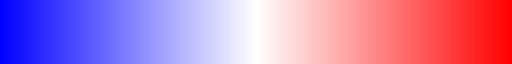

In [18]:
# Color map
color_len = 16

jet = colormaps.get_cmap('bwr')
jet_colors = jet(np.linspace(0, 1, color_len))[:,:-1]
jet

In [20]:
alphas = np.repeat(1, color_len) # np.arange(1, 1, 0.1) # color Alpha
print(alphas)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


# Merge target volumes

In [23]:
target_stats = []
for i, vertex in enumerate(target_vtk_volume.points()):
    RASp_coord = vertex
    image_coord = reference2imageCoord(RASp_coord, affine = stat.affine).astype(int)

    target_stats.append(t_stats[image_coord[0], image_coord[1], image_coord[2]])

         mesh.points() -> mesh.vertices
         (silence this with vedo.core.warnings['points_getter']=False)


In [25]:
# reverse y-axis
# target_vtk_volume = target_vtk_volume.clone(deep=False).mirror("y")

# Show


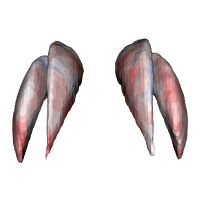

In [28]:
# Apply all configuration on volume
target_vtk_volume.cmap(jet_colors, target_stats, alpha=alphas, vmin=-0.5, vmax=0.5)
target_vtk_volume.add_scalarbar(horizontal=True)

In [34]:
# Show
vedo.show(target_vtk_volume, axes=0, viewup='z', interactive=True, mode=0).close()
# vedo.show(target_vtk_volume, __doc__, viewup="z", axes=0).close()